In [ ]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn imbalanced-learn joblib flask

In [ ]:
# Import libraries
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    f1_score
)

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

print("All libraries imported successfully.")

All libraries imported successfully.


In [ ]:
# Create folder
BASE_DIR = "/content/fraud_detection_project"

DATA_DIR = os.path.join(BASE_DIR, "data")
MODEL_DIR = os.path.join(BASE_DIR, "models")
PLOT_DIR = os.path.join(BASE_DIR, "plots")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

print("Project folders created successfully.")
print("Project location:", BASE_DIR)

Project folders created successfully.
Project location: /content/fraud_detection_project


In [ ]:
# Dataset configuration
N_TRANSACTIONS = 50000
FRAUD_RATE = 0.017

N_FRAUD = int(N_TRANSACTIONS * FRAUD_RATE)
N_LEGITIMATE = N_TRANSACTIONS - N_FRAUD

print("Total Transactions :", N_TRANSACTIONS)
print("Legitimate         :", N_LEGITIMATE)
print("Fraud              :", N_FRAUD)
print("Fraud Rate         :", round(N_FRAUD / N_TRANSACTIONS * 100, 2), "%")

Total Transactions : 50000
Legitimate         : 49150
Fraud              : 850
Fraud Rate         : 1.7 %


In [ ]:
# Generate Legitimate Transactions
rng = np.random.default_rng(RANDOM_STATE)

def generate_legitimate_data(n):

    data = pd.DataFrame({

        "transaction_amount":
            rng.gamma(2.0, 45, n),

        "transaction_hour":
            rng.normal(14, 4, n).clip(0, 23).astype(int),

        "day_of_week":
            rng.integers(0, 7, n),

        "customer_age":
            rng.normal(40, 12, n).clip(18, 85).astype(int),

        "account_age_days":
            rng.gamma(3, 350, n).clip(1, 5000),

        "num_transactions_last_24h":
            rng.poisson(2.2, n).clip(0, 40),

        "avg_transaction_amount_30d":
            rng.gamma(2, 40, n),

        "distance_from_home_km":
            rng.exponential(8, n).clip(0, 500),

        "distance_from_last_txn_km":
            rng.exponential(5, n).clip(0, 500),

        "is_foreign_transaction":
            rng.choice([0, 1], n, p=[0.94, 0.06]),

        "is_online_transaction":
            rng.choice([0, 1], n, p=[0.55, 0.45]),

        "used_chip":
            rng.choice([0, 1], n, p=[0.35, 0.65]),

        "new_device":
            rng.choice([0, 1], n, p=[0.92, 0.08]),

        "merchant_risk_score":
            rng.beta(2, 6, n),

        "card_present":
            rng.choice([0, 1], n, p=[0.45, 0.55]),

        "num_failed_pin_attempts":
            rng.choice([0, 1, 2], n, p=[0.96, 0.03, 0.01])
    })

    data["is_fraud"] = 0

    return data

print("Legitimate data generation function created.")

Legitimate data generation function created.


In [ ]:
# Generate Fraud Transactions
def generate_fraud_data(n):

    hour_weights = np.array([
        3 if 0 <= hour <= 5 else 1
        for hour in range(24)
    ], dtype=float)

    hour_probabilities = hour_weights / hour_weights.sum()

    data = pd.DataFrame({

        "transaction_amount":
            rng.gamma(1.4, 220, n),

        "transaction_hour":
            rng.choice(
                np.arange(24),
                n,
                p=hour_probabilities
            ),

        "day_of_week":
            rng.integers(0, 7, n),

        "customer_age":
            rng.normal(40, 14, n).clip(18, 85).astype(int),

        "account_age_days":
            rng.gamma(1.2, 200, n).clip(1, 5000),

        "num_transactions_last_24h":
            rng.poisson(6.5, n).clip(0, 60),

        "avg_transaction_amount_30d":
            rng.gamma(1.5, 35, n),

        "distance_from_home_km":
            rng.exponential(120, n).clip(0, 3000),

        "distance_from_last_txn_km":
            rng.exponential(180, n).clip(0, 3000),

        "is_foreign_transaction":
            rng.choice([0, 1], n, p=[0.55, 0.45]),

        "is_online_transaction":
            rng.choice([0, 1], n, p=[0.20, 0.80]),

        "used_chip":
            rng.choice([0, 1], n, p=[0.80, 0.20]),

        "new_device":
            rng.choice([0, 1], n, p=[0.45, 0.55]),

        "merchant_risk_score":
            rng.beta(5, 2, n),

        "card_present":
            rng.choice([0, 1], n, p=[0.85, 0.15]),

        "num_failed_pin_attempts":
            rng.choice([0, 1, 2], n, p=[0.55, 0.30, 0.15])
    })

    data["is_fraud"] = 1

    return data

print("Fraud data generation function created.")

Fraud data generation function created.


In [ ]:
# Create final dataset
legitimate_data = generate_legitimate_data(N_LEGITIMATE)
fraud_data = generate_fraud_data(N_FRAUD)

df = pd.concat(
    [legitimate_data, fraud_data],
    ignore_index=True
)

df = df.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

df.insert(
    0,
    "transaction_id",
    [
        "TXN" + str(i).zfill(7)
        for i in range(len(df))
    ]
)

numeric_columns = [
    "transaction_amount",
    "avg_transaction_amount_30d",
    "distance_from_home_km",
    "distance_from_last_txn_km",
    "account_age_days",
    "merchant_risk_score"
]

df[numeric_columns] = df[numeric_columns].round(3)

DATA_PATH = os.path.join(
    DATA_DIR,
    "transactions.csv"
)

df.to_csv(
    DATA_PATH,
    index=False
)

print("Dataset created successfully.")
print("Dataset shape:", df.shape)
print("Saved at:", DATA_PATH)

Dataset created successfully.
Dataset shape: (50000, 18)
Saved at: /content/fraud_detection_project/data/transactions.csv


In [ ]:
# Display dataset
pd.set_option(
    "display.max_columns",
    None
)

display(df.head())

,transaction_id,transaction_amount,transaction_hour,day_of_week,customer_age,account_age_days,num_transactions_last_24h,avg_transaction_amount_30d,distance_from_home_km,distance_from_last_txn_km,is_foreign_transaction,is_online_transaction,used_chip,new_device,merchant_risk_score,card_present,num_failed_pin_attempts,is_fraud
0,TXN0000000,194.371,19,6,61,1024.755,3,47.367,10.098,8.030,0,0,1,0,0.306,0,0,0
1,TXN0000001,70.101,17,0,42,1258.125,1,112.808,7.748,2.495,0,0,1,0,0.174,1,0,0
2,TXN0000002,89.120,12,5,18,933.677,1,45.767,1.352,3.344,0,0,0,0,0.086,1,0,0
3,TXN0000003,99.543,10,5,51,1028.892,2,63.777,9.722,10.999,0,1,0,0,0.249,1,0,0
4,TXN0000004,90.105,14,4,73,273.282,2,40.715,8.178,10.718,0,0,0,0,0.136,0,0,0


In [ ]:
# Dataset information
print("Dataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nFraud Distribution:")
print(df["is_fraud"].value_counts())

print("\nFraud Percentage:")
print(
    round(
        df["is_fraud"].mean() * 100,
        2
    ),
    "%"
)

Dataset Shape:
(50000, 18)

Missing Values:
0

Fraud Distribution:
is_fraud
0    49150
1      850
Name: count, dtype: int64

Fraud Percentage:
1.7 %


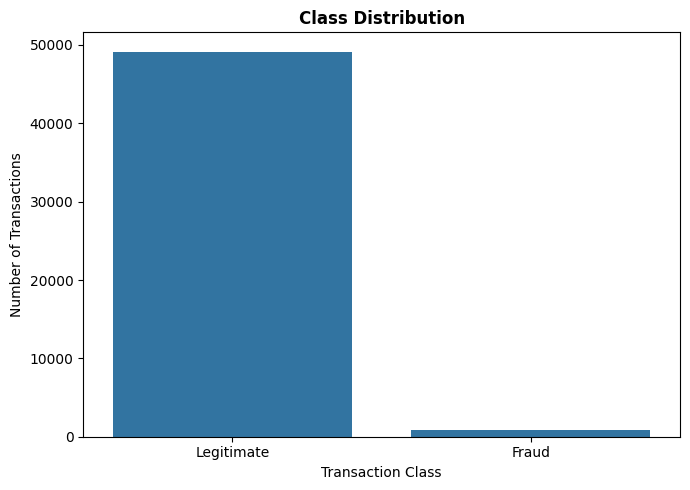

In [ ]:
# class distribution Graph
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="is_fraud"
)

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

plt.title(
    "Class Distribution",
    fontweight="bold"
)

plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "01_class_distribution.png"
    ),
    dpi=150
)

plt.show()

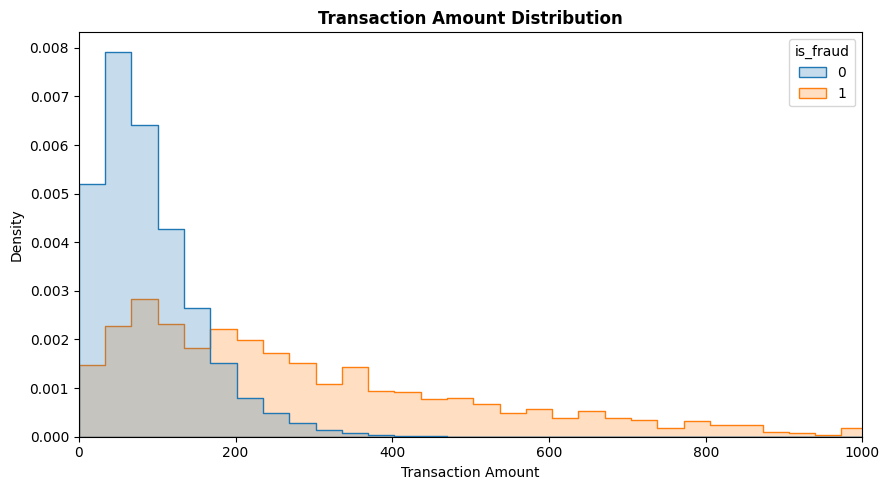

In [ ]:
# Transaction amount distribution
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="transaction_amount",
    hue="is_fraud",
    bins=50,
    stat="density",
    common_norm=False,
    element="step"
)

plt.title(
    "Transaction Amount Distribution",
    fontweight="bold"
)

plt.xlabel("Transaction Amount")
plt.ylabel("Density")

plt.xlim(0, 1000)

plt.tight_layout()

plt.show()

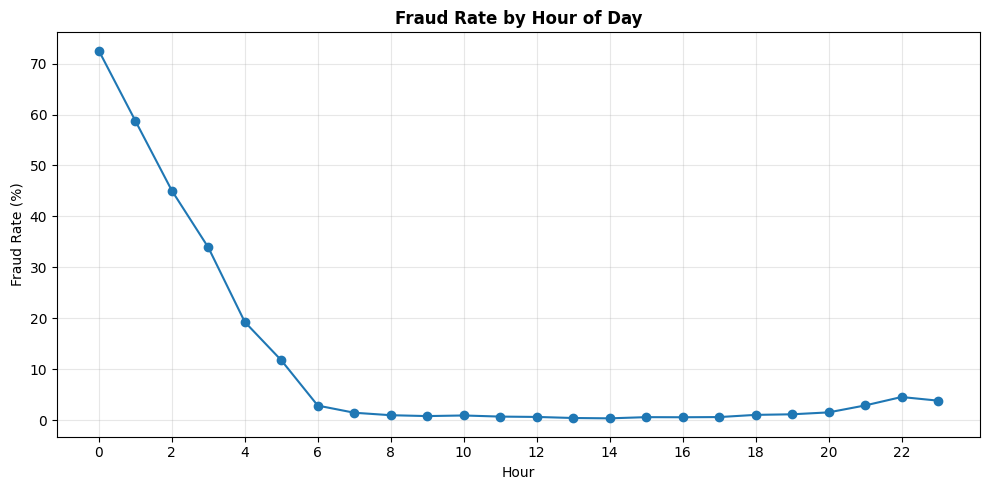

In [ ]:
# Fraud rate by hour
hourly_fraud = (
    df.groupby("transaction_hour")["is_fraud"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_fraud.index,
    hourly_fraud.values,
    marker="o"
)

plt.title(
    "Fraud Rate by Hour of Day",
    fontweight="bold"
)

plt.xlabel("Hour")
plt.ylabel("Fraud Rate (%)")

plt.xticks(
    range(0, 24, 2)
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

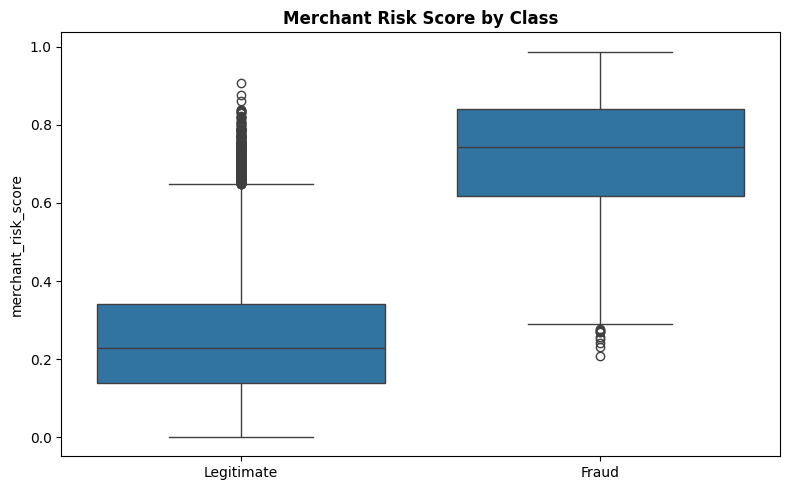

In [ ]:
# Merchant risk score
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="merchant_risk_score"
)

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

plt.title(
    "Merchant Risk Score by Class",
    fontweight="bold"
)

plt.xlabel("")

plt.tight_layout()

plt.show()

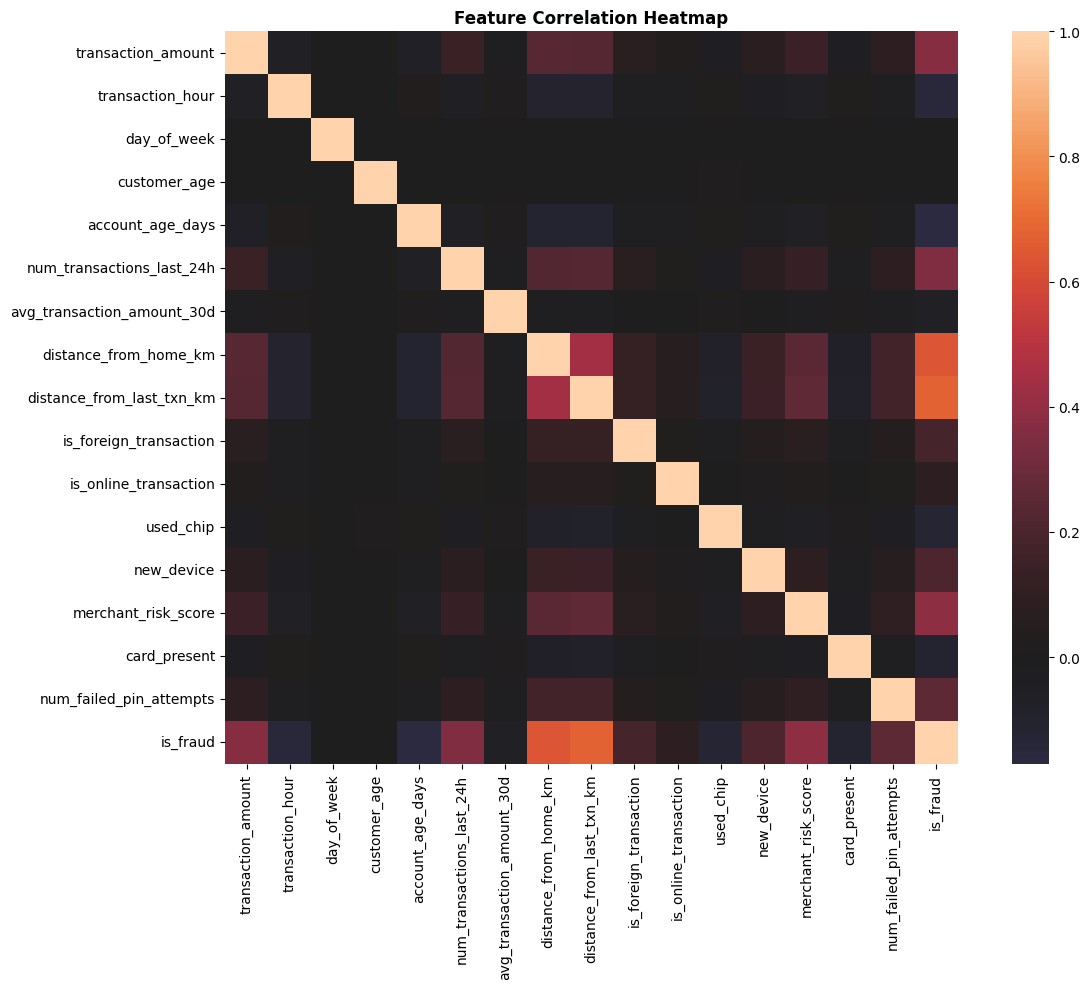

In [ ]:
# Correlation Heatmap
plt.figure(
    figsize=(13, 10)
)

numeric_df = df.select_dtypes(
    include="number"
)

correlation_matrix = numeric_df.corr()

sns.heatmap(
    correlation_matrix,
    center=0,
    square=True
)

plt.title(
    "Feature Correlation Heatmap",
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [ ]:
# Prepare x and Y
feature_columns = [
    column
    for column in df.columns
    if column not in [
        "transaction_id",
        "is_fraud"
    ]
]

X = df[feature_columns]

y = df["is_fraud"]

print("Number of features:", len(feature_columns))
print("X shape:", X.shape)
print("y shape:", y.shape)

Number of features: 16
X shape: (50000, 16)
y shape: (50000,)


In [ ]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

print(
    "Training data:",
    X_train.shape
)

print(
    "Testing data:",
    X_test.shape
)

print(
    "Training fraud rate:",
    round(y_train.mean() * 100, 2),
    "%"
)

print(
    "Testing fraud rate:",
    round(y_test.mean() * 100, 2),
    "%"
)

Training data: (37500, 16)
Testing data: (12500, 16)
Training fraud rate: 1.7 %
Testing fraud rate: 1.7 %


In [ ]:
# Standard Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Scaling completed successfully.")
print("Training scaled shape:", X_train_scaled.shape)
print("Testing scaled shape:", X_test_scaled.shape)

Scaling completed successfully.
Training scaled shape: (37500, 16)
Testing scaled shape: (12500, 16)


In [ ]:
# Random Oversampling
from imblearn.over_sampling import RandomOverSampler

oversampler = RandomOverSampler(
    random_state=RANDOM_STATE
)

X_train_resampled, y_train_resampled = oversampler.fit_resample(
    X_train_scaled,
    y_train
)

print(
    "Original training distribution:"
)

print(
    y_train.value_counts()
)

print(
    "\nBalanced training distribution:"
)

print(
    pd.Series(
        y_train_resampled
    ).value_counts()
)

print(
    "\nBalanced fraud rate:",
    round(
        y_train_resampled.mean() * 100,
        2
    ),
    "%"
)

Original training distribution:
is_fraud
0    36862
1      638
Name: count, dtype: int64

Balanced training distribution:
is_fraud
0    36862
1    36862
Name: count, dtype: int64

Balanced fraud rate: 50.0 %


In [ ]:
# Create Models
models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=10,
            random_state=RANDOM_STATE
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            max_depth=14,
            min_samples_leaf=3,
            n_jobs=-1,
            random_state=RANDOM_STATE
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.1,
            random_state=RANDOM_STATE
        )
}

print("Four models created successfully.")

for model_name in models:
    print("-", model_name)

Four models created successfully.
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting


In [ ]:
# Train + Evaluate All Models
results = {}
roc_data = {}
trained_models = {}

for name, model in models.items():

    print("\nTraining:", name)

    model.fit(
        X_train_resampled,
        y_train_resampled
    )

    y_pred = model.predict(
        X_test_scaled
    )

    y_probability = model.predict_proba(
        X_test_scaled
    )[:, 1]

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    auc = roc_auc_score(
        y_test,
        y_probability
    )

    average_precision = average_precision_score(
        y_test,
        y_probability
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    results[name] = {
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1-Score": f1,
        "ROC-AUC": auc,
        "Average Precision": average_precision,
        "Accuracy": report["accuracy"]
    }

    roc_data[name] = roc_curve(
        y_test,
        y_probability
    )

    trained_models[name] = model

    print(
        f"AUC = {auc:.4f} | "
        f"F1 = {f1:.4f} | "
        f"Precision = {report['1']['precision']:.4f} | "
        f"Recall = {report['1']['recall']:.4f}"
    )

results_df = pd.DataFrame(
    results
).T

display(
    results_df.round(4)
)


Training: Logistic Regression
AUC = 1.0000 | F1 = 0.9976 | Precision = 0.9953 | Recall = 1.0000

Training: Decision Tree
AUC = 0.9714 | F1 = 0.9501 | Precision = 0.9569 | Recall = 0.9434

Training: Random Forest
AUC = 1.0000 | F1 = 0.9929 | Precision = 1.0000 | Recall = 0.9858

Training: Gradient Boosting
AUC = 1.0000 | F1 = 0.9976 | Precision = 1.0000 | Recall = 0.9953


,Precision,Recall,F1-Score,ROC-AUC,Average Precision,Accuracy
Logistic Regression,0.9953,1.0000,0.9976,1.0000,1.0000,0.9999
Decision Tree,0.9569,0.9434,0.9501,0.9714,0.9109,0.9983
Random Forest,1.0000,0.9858,0.9929,1.0000,1.0000,0.9998
Gradient Boosting,1.0000,0.9953,0.9976,1.0000,1.0000,0.9999


In [ ]:
# selecting best model
best_model_name = (
    results_df["ROC-AUC"]
    .idxmax()
)

best_model = trained_models[
    best_model_name
]

print(
    "Best Model:",
    best_model_name
)

print(
    "Best ROC-AUC:",
    round(
        results_df.loc[
            best_model_name,
            "ROC-AUC"
        ],
        4
    )
)

Best Model: Logistic Regression
Best ROC-AUC: 1.0


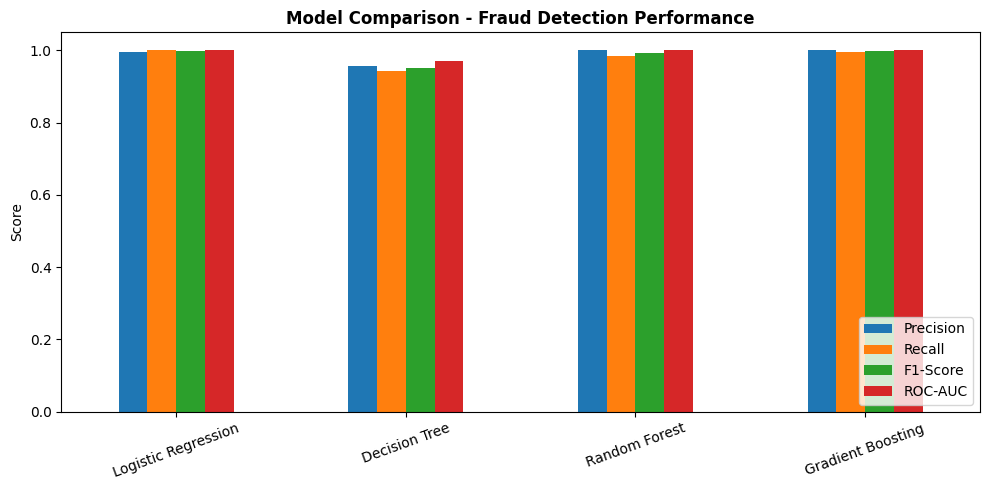

In [ ]:
# Model comparison Graph
comparison = results_df[
    [
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
]

comparison.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title(
    "Model Comparison - Fraud Detection Performance",
    fontweight="bold"
)

plt.ylabel("Score")
plt.ylim(0, 1.05)

plt.legend(
    loc="lower right"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()

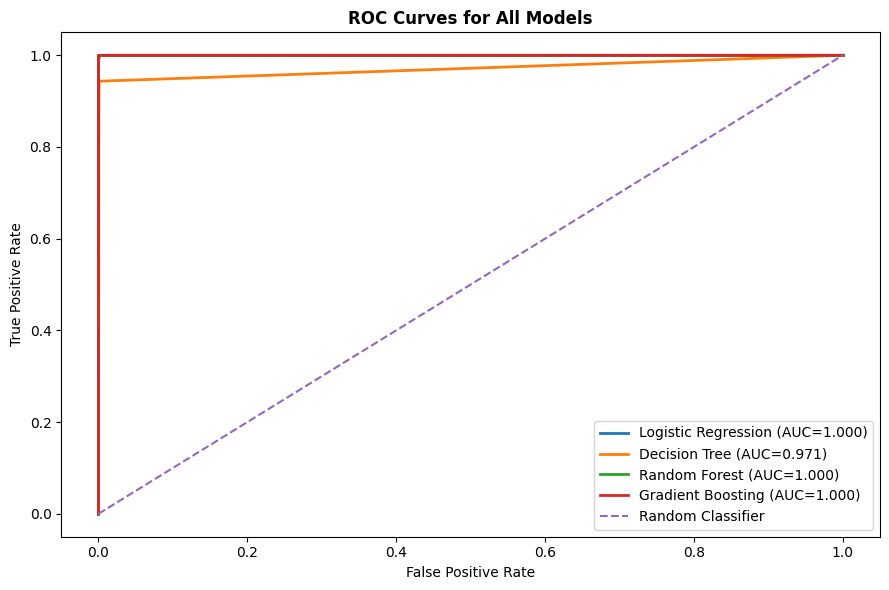

In [ ]:
# ROC curve
plt.figure(
    figsize=(9, 6)
)

for name, roc_values in roc_data.items():

    fpr, tpr, thresholds = roc_values

    auc = results[name]["ROC-AUC"]

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random Classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curves for All Models",
    fontweight="bold"
)

plt.legend()

plt.tight_layout()

plt.show()

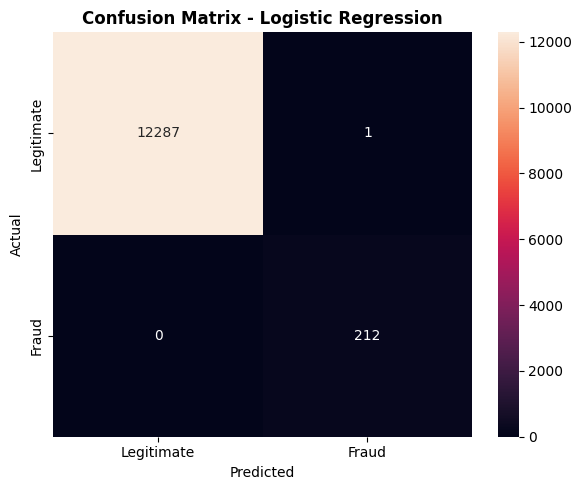

Confusion Matrix:
[[12287     1]
 [    0   212]]


In [ ]:
# Confusion matrix
best_predictions = best_model.predict(
    X_test_scaled
)

conf_matrix = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    xticklabels=[
        "Legitimate",
        "Fraud"
    ],
    yticklabels=[
        "Legitimate",
        "Fraud"
    ]
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    f"Confusion Matrix - {best_model_name}",
    fontweight="bold"
)

plt.tight_layout()

plt.show()

print("Confusion Matrix:")
print(conf_matrix)

In [ ]:
# Classification report
print(
    classification_report(
        y_test,
        best_predictions,
        target_names=[
            "Legitimate",
            "Fraud"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     12288
       Fraud       1.00      1.00      1.00       212

    accuracy                           1.00     12500
   macro avg       1.00      1.00      1.00     12500
weighted avg       1.00      1.00      1.00     12500



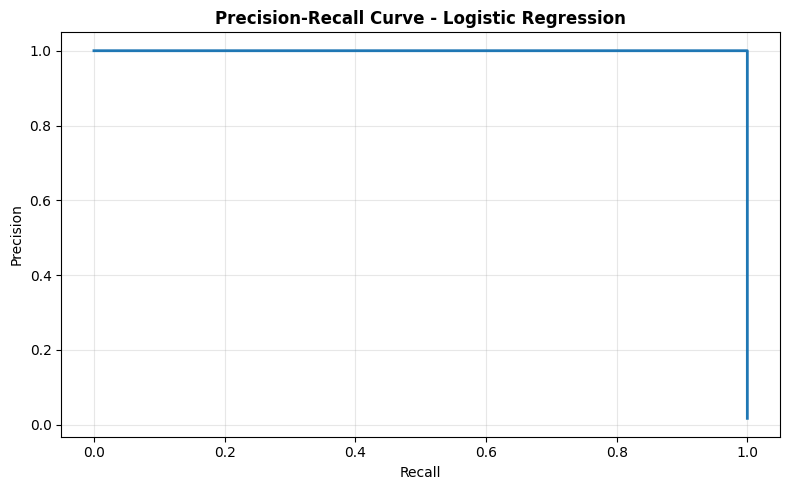

Average Precision: 1.0


In [ ]:
# Precision recall curve
best_probability = best_model.predict_proba(
    X_test_scaled
)[:, 1]

precision, recall, thresholds = precision_recall_curve(
    y_test,
    best_probability
)

average_precision = average_precision_score(
    y_test,
    best_probability
)

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    recall,
    precision,
    linewidth=2
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    f"Precision-Recall Curve - {best_model_name}",
    fontweight="bold"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

print(
    "Average Precision:",
    round(
        average_precision,
        4
    )
)

In [ ]:
# Feature Importance
if hasattr(
    best_model,
    "feature_importances_"
):

    importance = pd.Series(
        best_model.feature_importances_,
        index=feature_columns
    ).sort_values(
        ascending=False
    )

    plt.figure(
        figsize=(9, 6)
    )

    importance.head(10).sort_values().plot(
        kind="barh"
    )

    plt.title(
        "Top 10 Feature Importances",
        fontweight="bold"
    )

    plt.xlabel(
        "Importance"
    )

    plt.tight_layout()

    plt.show()

    display(
        importance.head(10).to_frame(
            "Importance"
        )
    )

else:

    print(
        "Feature importance is not available for this model."
    )

Feature importance is not available for this model.


In [ ]:
# Save Model
MODEL_PATH = os.path.join(
    MODEL_DIR,
    "fraud_detection_model.pkl"
)

SCALER_PATH = os.path.join(
    MODEL_DIR,
    "scaler.pkl"
)

FEATURE_PATH = os.path.join(
    MODEL_DIR,
    "feature_columns.pkl"
)

RESULT_PATH = os.path.join(
    MODEL_DIR,
    "model_comparison_results.json"
)

joblib.dump(
    best_model,
    MODEL_PATH
)

joblib.dump(
    scaler,
    SCALER_PATH
)

joblib.dump(
    feature_columns,
    FEATURE_PATH
)

with open(
    RESULT_PATH,
    "w"
) as file:

    json.dump(
        {
            "results":
                results,

            "best_model":
                best_model_name
        },
        file,
        indent=4
    )

print("All model files saved successfully.")
print(MODEL_PATH)
print(SCALER_PATH)
print(FEATURE_PATH)
print(RESULT_PATH)

All model files saved successfully.
/content/fraud_detection_project/models/fraud_detection_model.pkl
/content/fraud_detection_project/models/scaler.pkl
/content/fraud_detection_project/models/feature_columns.pkl
/content/fraud_detection_project/models/model_comparison_results.json


In [ ]:
# Load Model
loaded_model = joblib.load(
    MODEL_PATH
)

loaded_scaler = joblib.load(
    SCALER_PATH
)

loaded_features = joblib.load(
    FEATURE_PATH
)

print("Model loaded successfully.")

Model loaded successfully.


In [ ]:
# Real time fraud detection
def predict_transaction(transaction):

    transaction_df = pd.DataFrame(
        [transaction]
    )

    transaction_df = transaction_df[
        loaded_features
    ]

    scaled_transaction = loaded_scaler.transform(
        transaction_df
    )

    probability = loaded_model.predict_proba(
        scaled_transaction
    )[0, 1]

    prediction = (
        "FRAUD"
        if probability >= 0.5
        else "LEGITIMATE"
    )

    if probability >= 0.75:
        risk = "HIGH RISK"

    elif probability >= 0.40:
        risk = "MEDIUM RISK"

    else:
        risk = "LOW RISK"

    return {
        "fraud_probability":
            round(float(probability), 4),

        "prediction":
            prediction,

        "risk_tier":
            risk
    }

print("Prediction function created successfully.")

Prediction function created successfully.


In [ ]:
# Test fraud detection
suspicious_transaction = {

    "transaction_amount": 1450.00,

    "transaction_hour": 3,

    "day_of_week": 5,

    "customer_age": 29,

    "account_age_days": 40,

    "num_transactions_last_24h": 9,

    "avg_transaction_amount_30d": 60.0,

    "distance_from_home_km": 620.0,

    "distance_from_last_txn_km": 480.0,

    "is_foreign_transaction": 1,

    "is_online_transaction": 1,

    "used_chip": 0,

    "new_device": 1,

    "merchant_risk_score": 0.87,

    "card_present": 0,

    "num_failed_pin_attempts": 2
}

result = predict_transaction(
    suspicious_transaction
)

print(result)

{'fraud_probability': 1.0, 'prediction': 'FRAUD', 'risk_tier': 'HIGH RISK'}


In [ ]:
# Test normal transaction
normal_transaction = {

    "transaction_amount": 82.50,

    "transaction_hour": 14,

    "day_of_week": 2,

    "customer_age": 35,

    "account_age_days": 900,

    "num_transactions_last_24h": 2,

    "avg_transaction_amount_30d": 75.0,

    "distance_from_home_km": 3.2,

    "distance_from_last_txn_km": 1.5,

    "is_foreign_transaction": 0,

    "is_online_transaction": 1,

    "used_chip": 1,

    "new_device": 0,

    "merchant_risk_score": 0.12,

    "card_present": 1,

    "num_failed_pin_attempts": 0
}

result = predict_transaction(
    normal_transaction
)

print(result)

{'fraud_probability': 0.0, 'prediction': 'LEGITIMATE', 'risk_tier': 'LOW RISK'}


In [ ]:
# Flask API
from flask import Flask, request, jsonify

app = Flask(__name__)


@app.route("/", methods=["GET"])
def home():

    return jsonify({

        "service":
            "AI-Powered Financial Fraud Detection System",

        "status":
            "running",

        "endpoint":
            "/predict"
    })


@app.route(
    "/predict",
    methods=["POST"]
)
def predict_api():

    try:

        transaction = request.get_json(
            force=True
        )

        missing_fields = [
            feature
            for feature in loaded_features
            if feature not in transaction
        ]

        if missing_fields:

            return jsonify({
                "error":
                    f"Missing fields: {missing_fields}"
            }), 400

        result = predict_transaction(
            transaction
        )

        return jsonify(
            result
        ), 200

    except Exception as error:

        return jsonify({
            "error":
                str(error)
        }), 500


print("Flask API created successfully.")

Flask API created successfully.


In [ ]:
# Test flask API
client = app.test_client()

response = client.post(
    "/predict",
    json=suspicious_transaction
)

print(
    "Status Code:",
    response.status_code
)

print(
    "API Response:"
)

print(
    response.get_json()
)

Status Code: 200
API Response:
{'fraud_probability': 1.0, 'prediction': 'FRAUD', 'risk_tier': 'HIGH RISK'}
